# Healthcare Data Breaches: Do Business Associates Affect Breach Impact?

**Author:** Allison Evanich  
**Course Project:** DSC 530 Final Project  
**Date:** 6/3/2024  

## Project Overview
This project analyzes a healthcare data breach dataset to understand what factors are associated with breach impact, measured as the **number of individuals affected** (`num_affected`).

### Research Question
**Do breaches involving a business associate (BA presence) tend to affect more individuals than breaches without BA involvement?**

### Why this matters
Business associates (e.g., vendors, third-party service providers) often handle protected health information on behalf of covered entities. Understanding whether BA involvement is associated with larger breach impact can help organizations prioritize risk management, vendor oversight, and incident response planning.

### Analysis Plan (high level)
1. **Load and clean** the dataset; define key variables.
2. Perform **EDA** to understand distributions and common breach characteristics.
3. Use **distribution plots** (including log-scale views) to describe heavy skew.
4. Compare BA-present vs BA-not-present breaches using **robust, nonparametric inference** (permutation test on the median + bootstrap confidence interval).
5. Fit a **regression model** to check whether BA presence remains associated with breach impact after controlling for breach type and breach location.
6. Summarize findings with clear interpretation and limitations.

> **Note on skew:** Breach sizes are typically **heavy-tailed** (many small events and a few extremely large events). For this reason, the **median** and resampling-based methods are emphasized over mean-based parametric tests.

## How to run this notebook
1. Clone the repository.
2. Install requirements: `pip install pandas numpy matplotlib statsmodels`
3. Open the notebook and run all cells.
4. Ensure `cleaned_data.csv' is in the  directoryry.
ory.ory.ory.


# Loading and Cleaning the Data

For my Final Project I used a Breach Report dataset from Kaggle that I explored using RStudio in a previous course. This dataset contains information on over 860 entries involving major healthcare data breaches that occurred in the United States between 2009-2016. Through exploratory data analysis my goal was to use this dataset to identify patterns or trends related to data breach events. This could provide valuable insights on incidents that occured and help mitigate future breaches for organizations. The following will list the steps I took to download and clean the Kaggle dataset from R, perform data exploration, and analyze with statistical methods. For my research question I wanted to know: Do data breaches involving the presence of a business associate affect more individuals?

In [167]:
import pandas as pd

file_path = r"C:\Users\Allis\OneDrive\DSC530\cleaned_data.csv"
 
df = pd.read_csv(file_path)
df.head()

,index,State,Individuals Affected,Breach Submission Date,Type of Breach,Location of Breached Information,Business Associate Present
0,0,TX,1000.00,10/21/09,Theft,Paper/Films,No
1,1,MO,1000.00,10/28/09,Theft,Network Server,No
2,2,AK,501.00,10/30/09,Theft,"Other, Other Portable Electronic Device",No
3,3,DC,3800.00,11/17/09,Loss,Laptop,No
4,4,CA,5166.00,11/20/09,Theft,Desktop Computer,No


Missing data was removed from this dataset prior to manipulation in Jupyter. In addition, several variables were excluded in order to consolidate what is needed for this analysis. 

In [169]:
df.rename(columns={'index':'breachid', 
                   'State': 'state', 
                   'Individuals Affected': 'num_affected',
                   'Breach Submission Date': 'entry_date',
                   'Type of Breach': 'breach_type',
                   'Location of Breached Information': 'breach_location', 
                   'Business Associate Present': 'ba_presence'}, inplace=True)

# --- Basic type cleanup (prevents errors in stats/plots) ---
df['num_affected'] = (
    pd.to_numeric(df['num_affected'], errors='coerce')
)
df = df.dropna(subset=['num_affected']).copy()
df['num_affected'] = df['num_affected'].astype(int)

In [170]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   breachid         1620 non-null   int64 
 1   state            1620 non-null   object
 2   num_affected     1620 non-null   int32 
 3   entry_date       1620 non-null   object
 4   breach_type      1620 non-null   object
 5   breach_location  1620 non-null   object
 6   ba_presence      1620 non-null   object
dtypes: int32(1), int64(1), object(5)
memory usage: 82.4+ KB


# Description of Variables

For the explorations in this project, I used the following variables:

- _breachid_: The integer ID of the data breach entry.
- _state_: The U.S. state where the breach occurred.
- _num_affected_: The number of individuals affected by the breach.
- _entry_date_: The date the breach was submitted.
- _breach_type_: The type of breach that occurred, such as unauthorized access/disclosure or loss of hardware/electronic media.
- _breach_location_: The location of the breached information, such as paper records or electronic devices.
- _ba_presence_: Indicates whether a business associate was present (Yes/No).

# Exploratory Data Analysis (EDA)¶

In this section, we summarize the dataset and visualize key variables to understand overall patterns (e.g., breach counts by year, breach type, breach location, and BA presence). These descriptive results provide context before formal statistical comparisons.


In [174]:
df.state.value_counts(sort=True)

state
CA    195
TX    134
FL    110
NY    103
IL     90
PA     57
OH     54
IN     52
GA     50
NC     41
MI     41
MA     41
TN     40
WA     40
MN     39
AZ     36
MO     34
KY     33
MD     31
CO     30
VA     29
OR     25
CT     25
NJ     24
SC     22
AL     21
PR     19
OK     16
AR     16
NM     16
LA     14
WI     14
IA     12
KS     11
UT     11
NV     10
MT     10
RI      9
DC      9
MS      8
NE      8
AK      6
WY      6
WV      5
SD      4
NH      4
ND      3
ID      3
ME      3
HI      2
VT      2
DE      2
Name: count, dtype: int64

The first thing I wanted to know for the _state_ variable was each state's population which I looked up online. It would make sense that the larger the population, the more data breaches there would be. In almost exact order, the first 7 states listed in order of data breaches from highest to lowest are the largest populated states in the US. Indiana, however, is the 17th largest populated state in the US, but falls at 8th for the largest number of data breaches, out of order from the rest of the states. This is something to note and possibly take a closer look at, if not in this analysis, then in future analysis.

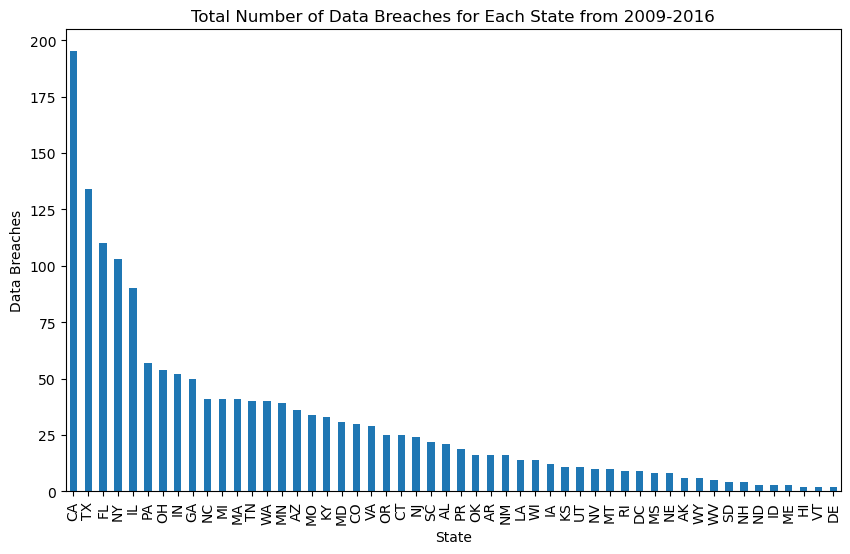

In [176]:
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)  
pd.set_option('display.float_format', '{:.2f}'.format)  
fig, ax = plt.subplots(figsize=(10, 6))

df['state'].value_counts().plot(kind='bar', ax=ax)
ax.set_title('Total Number of Data Breaches for Each State from 2009-2016')
ax.set_xlabel('State')
ax.set_ylabel('Data Breaches')
plt.show()

When taking a look at the histogram of the variable _state_, you can see the distribution for the amount of data breach entries by state from 2009-2016. The data is skewed right with a long right tail. The histogram was plotted by value counts. However, this does make it easy to visually see which states have the highest number of data breach entries. 

In [178]:
df.num_affected.value_counts(sort=True)

num_affected
1000      25
500       22
2000      21
3000      15
1500      13
          ..
8500       1
109000     1
2261       1
834        1
7242       1
Name: count, Length: 1175, dtype: int64

After taking a closer look at the _num_affected_ variable, it was apparent that some entities reported exact numbers of affected individuals while some rounded. This could definitely pose a quality issue if entries vary in accuracy. Most likely, these numbers are estimates because the actual number of individuals affected is unknown. For this reason, I will keep the data as is. However, if I wanted to collect the data again, I would be sure that all entities are reporting the exact amount of individuals affected and are not rounding.  

In [180]:
df.num_affected.describe()

count       1620.00
mean      103391.31
std      2013488.33
min          500.00
25%          994.25
50%         2300.00
75%         7409.00
max     78800000.00
Name: num_affected, dtype: float64

After look at the descriptive statistics, I found that the mean of _num_affected_ was 103,391 which was larger than what I would have expected. Sensing the max value of 78,800,000 was an outlier, I plotted the distribution with both a box plot and scatter plot. 

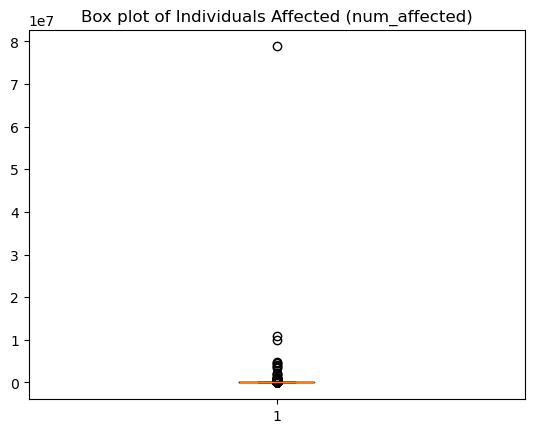

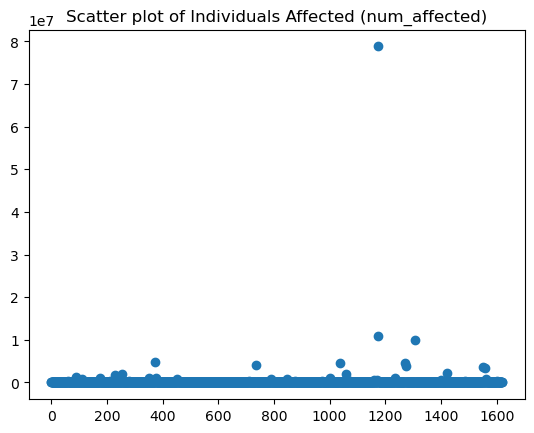

In [182]:
plt.boxplot(df['num_affected'])
plt.title("Box plot of Individuals Affected (num_affected)")
plt.show()

plt.scatter(df.index, df['num_affected'])
plt.title("Scatter plot of Individuals Affected (num_affected)")
plt.show()

After looking at the plots of the data, I decided to exclude the row with the outlier of 78,800,000 from the dataset since it was clear that it was probably a typo, and sorted out any other values that may be outliers. 

In [184]:
q_low = df["num_affected"].quantile(0.01)
q_hi  = df["num_affected"].quantile(0.99)

df = df[(df["num_affected"] < q_hi) & (df["num_affected"] > q_low)]

In [185]:
# descriptive statistics after removing outliers
df.num_affected.describe()

count      1581.00
mean      17439.07
std       78509.65
min         501.00
25%        1000.00
50%        2300.00
75%        7226.00
max     1055489.00
Name: num_affected, dtype: float64

In [186]:
df.entry_date.value_counts(sort=True)

entry_date
2/26/16     9
4/2/15      8
4/25/14     7
12/6/13     7
3/21/14     6
           ..
6/28/11     1
1/8/14      1
6/27/11     1
1/11/14     1
10/21/09    1
Name: count, Length: 1002, dtype: int64

In [187]:
df['entry_date'] = pd.to_datetime(df['entry_date'], errors='coerce')

df['entry_year'] = df['entry_date'].dt.year
df.head()

C:\Users\Allis\AppData\Local\Temp\ipykernel_22904\1278294940.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['entry_date'] = pd.to_datetime(df['entry_date'], errors='coerce')


,breachid,state,num_affected,entry_date,breach_type,breach_location,ba_presence,entry_year
0,0,TX,1000,2009-10-21,Theft,Paper/Films,No,2009
1,1,MO,1000,2009-10-28,Theft,Network Server,No,2009
2,2,AK,501,2009-10-30,Theft,"Other, Other Portable Electronic Device",No,2009
3,3,DC,3800,2009-11-17,Loss,Laptop,No,2009
4,4,CA,5166,2009-11-20,Theft,Desktop Computer,No,2009


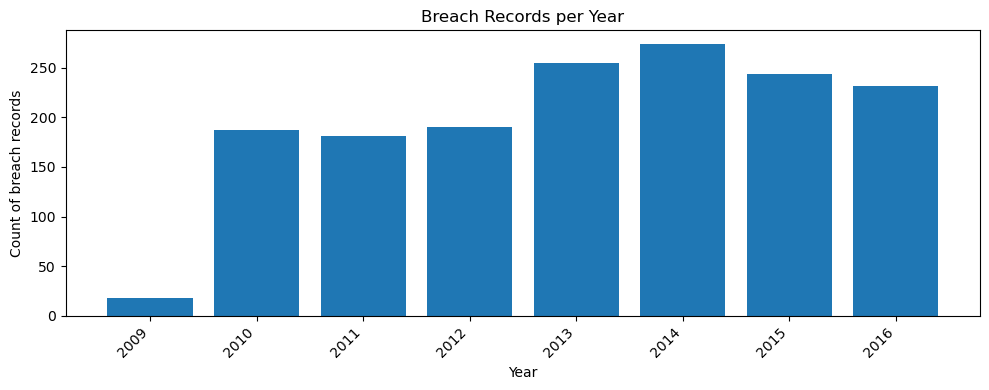

In [188]:
# Breach entries per year (count)
year_counts = df["entry_year"].value_counts().sort_index()

plt.figure(figsize=(10, 4))
plt.bar(year_counts.index.astype(str), year_counts.values)
plt.xlabel("Year")
plt.ylabel("Count of breach records")
plt.title("Breach Records per Year")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

I was really happy with how this graph turned out. By creating a new column that added together all of the data breaches for each year, we are able to see the amount reported for each year and whether or not there is a trend. The data skewed left would indicate perhaps there was better tracking of data breaches over the years. Potentially, as the numbers fell back down around 2015 there were processes put in place to prevent data breaches from occuring. I would be interested to see the different breach types over the years and how the amounts changed. 

In [190]:
df.breach_type.value_counts(sort=True)

breach_type
Theft                                                         684
Unauthorized Access/Disclosure                                375
Hacking/IT Incident                                           201
Loss                                                          111
Other                                                          76
Improper Disposal                                              46
Theft, Unauthorized Access/Disclosure                          24
Loss, Theft                                                    15
Unknown                                                         8
Other, Unauthorized Access/Disclosure                           7
Hacking/IT Incident, Unauthorized Access/Disclosure             7
Improper Disposal, Loss, Theft                                  3
Other, Theft                                                    3
Improper Disposal, Loss                                         3
Loss, Unauthorized Access/Disclosure                            

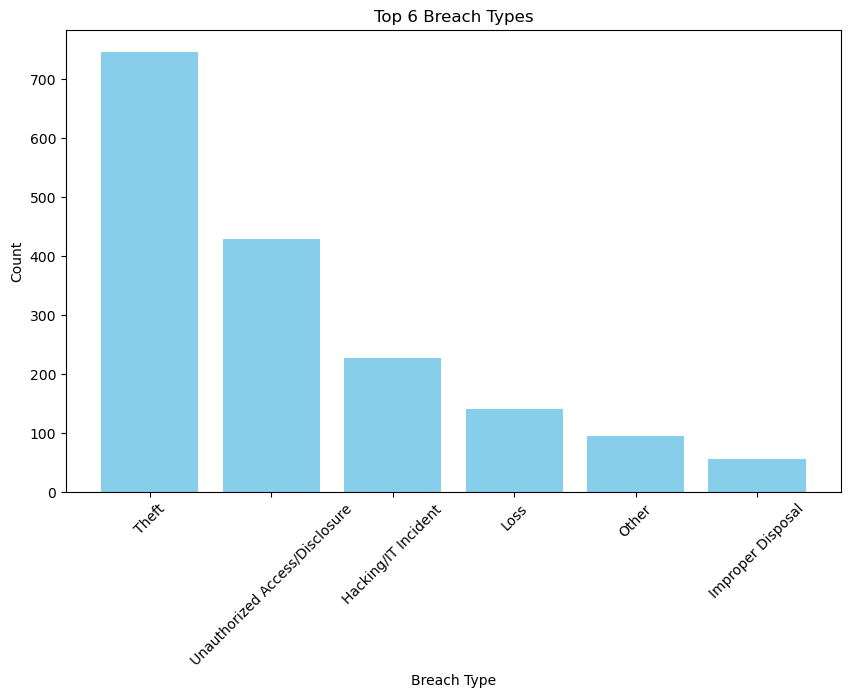

In [191]:
breach_type_data = {
    'breach_type': [
        'Theft', 'Unauthorized Access/Disclosure', 'Hacking/IT Incident', 'Loss', 'Other',
        'Improper Disposal', 'Theft, Unauthorized Access/Disclosure', 'Loss, Theft', 'Unknown',
        'Other, Unauthorized Access/Disclosure', 'Hacking/IT Incident, Unauthorized Access/Disclosure',
        'Improper Disposal, Loss, Theft', 'Other, Theft', 'Improper Disposal, Loss',
        'Loss, Unauthorized Access/Disclosure', 'Loss, Other', 'Hacking/IT Incident, Other',
        'Other, Unknown', 'Other, Theft, Unauthorized Access/Disclosure',
        'Loss, Unauthorized Access/Disclosure, Unknown', 'Hacking/IT Incident, Other, Unauthorized Access/Disclosure',
        'Hacking/IT Incident, Theft', 'Loss, Other, Theft', 'Loss, Unknown',
        'Hacking/IT Incident, Theft, Unauthorized Access/Disclosure', 'Improper Disposal, Unauthorized Access/Disclosure'
    ],
    'count': [
        696, 382, 215, 113, 76, 49, 24, 15, 9, 7, 7, 3, 3, 3, 3, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1
    ]
}

# Create DataFrame
breach_type_df = pd.DataFrame(breach_type_data)

# Initialize a dictionary to hold the aggregated counts
aggregated_counts = {}

# Function to aggregate counts
def aggregate_counts(row):
    types = row['breach_type'].split(', ')
    for breach_type in types:
        if breach_type in aggregated_counts:
            aggregated_counts[breach_type] += row['count']
        else:
            aggregated_counts[breach_type] = row['count']

# Apply the function to each row
breach_type_df.apply(aggregate_counts, axis=1)

# Convert the dictionary to a DataFrame
aggregated_df = pd.DataFrame(list(aggregated_counts.items()), columns=['breach_type', 'count'])

# Sort the DataFrame by count in descending order and get the top 6 breach types
top_six_breach_types = aggregated_df.sort_values(by='count', ascending=False).head(6)

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.bar(top_six_breach_types['breach_type'], top_six_breach_types['count'], color='skyblue')
plt.xlabel('Breach Type')
plt.ylabel('Count')
plt.title('Top 6 Breach Types')
plt.xticks(rotation=45)
plt.show()

It ended up being more difficult than anticipated trying to consolidate the _breach_type_ variable. There were several entries that I felt fell into multiple categories. However, this histogram does a good job of depicting the majority of the entries and the most frequent types of data breach types. 

In [193]:
df.breach_type.describe()

count      1581
unique       26
top       Theft
freq        684
Name: breach_type, dtype: object

In [194]:
df.breach_location.value_counts(sort=True)

breach_location
Paper/Films                                                                                                                         366
Laptop                                                                                                                              271
Network Server                                                                                                                      205
Other                                                                                                                               149
Email                                                                                                                               127
Desktop Computer                                                                                                                    124
Other Portable Electronic Device                                                                                                     87
Electronic Medical Record       

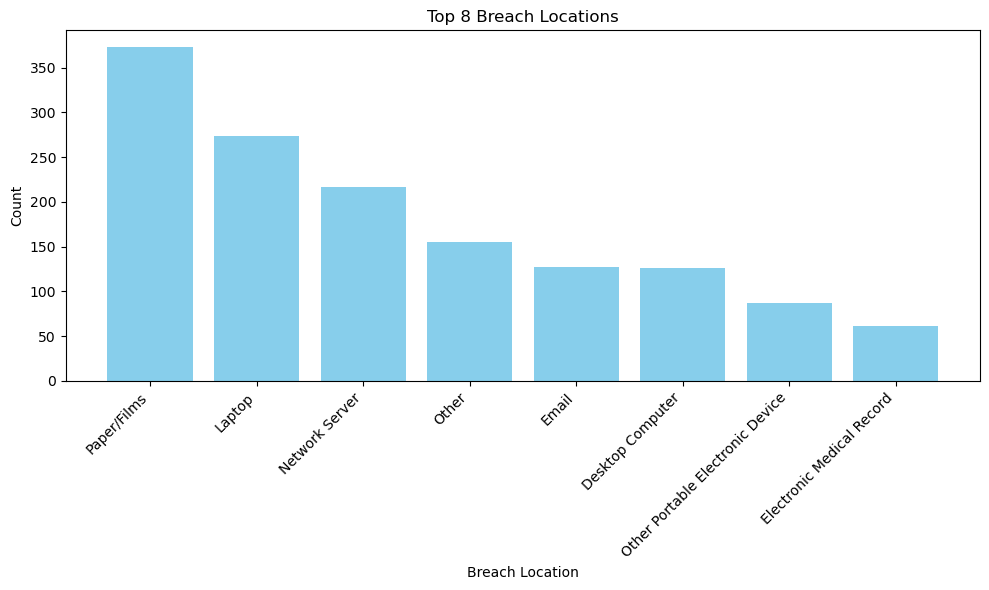

In [195]:
categories = ['Paper/Films', 'Laptop', 'Network Server', 'Other', 'Email', 'Desktop Computer', 'Other Portable Electronic Device', 
              'Electronic Medical Record']
counts = [373, 274, 217, 155, 127, 126, 87, 61]

plt.figure(figsize=(10, 6))
plt.bar(categories, counts, color='skyblue')
plt.title('Top 8 Breach Locations')
plt.xlabel('Breach Location')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')  
plt.tight_layout()
plt.show()

The first thing I noticed for this variable is the amount of breaches with several different locations, similar to breach type, which made it a little more difficult for analysis. For this reason, I decided to only look at the top 8 locations to get an idea of the types we have and how they compare to one another. 

In [197]:
df.breach_location.describe()

count            1581
unique             57
top       Paper/Films
freq              366
Name: breach_location, dtype: object

In [198]:
df.ba_presence.value_counts(sort=True)

ba_presence
No     1290
Yes     291
Name: count, dtype: int64

In [199]:
import numpy as np

# Filter the data where business associate is present
ba_present = df[df['ba_presence'] == 'Yes']

# Filter the data where business associate is not present
ba_not_present = df[df['ba_presence'] == 'No']

# Calculate the total number of individuals affected in each group
total_affected_ba_present = ba_present['num_affected'].sum()
total_affected_ba_present_round = np.round(total_affected_ba_present)

total_affected_ba_not_present = ba_not_present['num_affected'].sum()
total_affected_ba_not_present_round = np.round(total_affected_ba_not_present)

# Calculate the mean number of individuals affected in each group
mean_affected_ba_present = ba_present['num_affected'].mean()
mean_affected_ba_present_round = np.round(mean_affected_ba_present)
mean_affected_ba_not_present = ba_not_present['num_affected'].mean()
mean_affected_ba_not_present_round = np.round(mean_affected_ba_not_present)

print(f'Total individuals affected when business associate is present: {total_affected_ba_present_round}')
print(f'Total individuals affected when business associate is not present: {total_affected_ba_not_present_round}')
print(f'Mean individuals affected when business associate is present: {mean_affected_ba_present_round}')
print(f'Mean individuals affected when business associate is not present: {mean_affected_ba_not_present_round}')

Total individuals affected when business associate is present: 6445637
Total individuals affected when business associate is not present: 21125537
Mean individuals affected when business associate is present: 22150.0
Mean individuals affected when business associate is not present: 16376.0


I found these statistics to be really interesting. In summary, the total number of individuals affected by data breaches is greater when a business associate is not present (21,125,537 > 6,445,637). However, on average, more individuals are affected when a business associate is present (22,150 > 16,376).

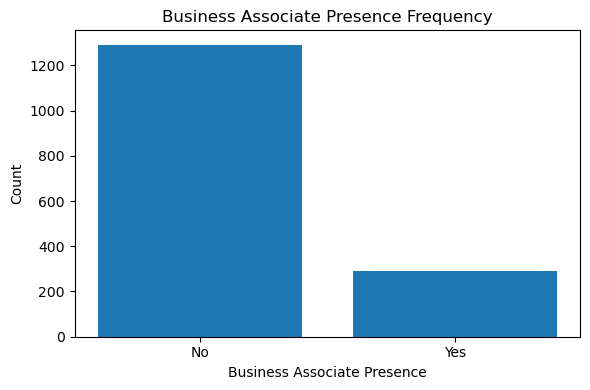

In [201]:
ba_counts = df["ba_presence"].value_counts(dropna=False)

plt.figure(figsize=(6, 4))
plt.bar(ba_counts.index.astype(str), ba_counts.values)
plt.xlabel("Business Associate Presence")
plt.ylabel("Count")
plt.title("Business Associate Presence Frequency")
plt.tight_layout()
plt.show()

My research question asks if more individuals are affected by data breaches when business associates are present. Although this histogram depicts that only about one fourth of data breaches involve a business associate, it does not tell us the scale of the breaches when they do happen. Therefore, there is more to investigate. 

# Comparative Analysis using Probability Mass Function (PMF)

Because `num_affected` is highly right-skewed, a log-transformed view is used to compare the shape of breach sizes between groups. This replaces the need for a traditional PMF from external libraries and keeps the notebook fully reproducible using pandas/NumPy/Matplotlib.


I wanted to see the difference in the number of individuals affected by data breaches with and without a business associate present. When I tried creating a PMF of the data originally, I realized I would have to apply a logarithmic transformation to handle the large range of values and adjust the bin width to give a good visualization of the data. 

C:\Users\Allis\AppData\Local\Temp\ipykernel_22904\4189068001.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({"Yes": 1, "No": 0})


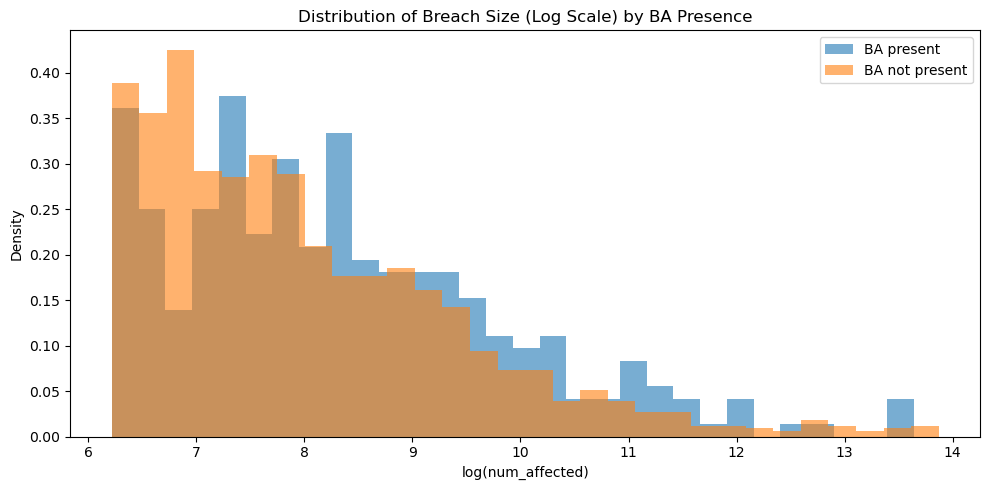

In [205]:
import numpy as np

# Create a stable binary column without chained-inplace behavior
df["ba_presence_bin"] = (
    df["ba_presence"]
      .replace({"Yes": 1, "No": 0})
      .astype("Int64")
)

# Clean outcome
df["num_affected"] = pd.to_numeric(df["num_affected"], errors="coerce")
df_clean = df.dropna(subset=["num_affected", "ba_presence_bin"]).copy()
df_clean = df_clean[df_clean["num_affected"] > 0]

ba_present = df_clean[df_clean["ba_presence_bin"] == 1]
ba_not_present = df_clean[df_clean["ba_presence_bin"] == 0]

# Log-transform for visualization (natural log)
ba_present = ba_present.assign(log_num_affected=np.log(ba_present["num_affected"]))
ba_not_present = ba_not_present.assign(log_num_affected=np.log(ba_not_present["num_affected"]))

plt.figure(figsize=(10, 5))
plt.hist(ba_present["log_num_affected"], bins=30, density=True, alpha=0.6, label="BA present")
plt.hist(ba_not_present["log_num_affected"], bins=30, density=True, alpha=0.6, label="BA not present")
plt.xlabel("log(num_affected)")
plt.ylabel("Density")
plt.title("Distribution of Breach Size (Log Scale) by BA Presence")
plt.legend()
plt.tight_layout()
plt.show()

If we look at the distribution of data between the two scenarios, we can see that for the most part when affect size goes up, there is less likely a business associate present. As the affect size gets smaller the amounts between the two even out. With this information I would be interested to see which breach types and breach locations involve business associates the most and vice versa to see if there is a trend.

# Cumulative Distribution Function (CDF)

The **cumulative distribution function (CDF)** shows the proportion of observations at or below a given value. CDFs are especially helpful for skewed data because they show how quickly most observations accumulate and how long the tail extends.


Next, I wanted to look at the CDF of data breach entries over time to see if the number of entries listing a business associate present shows the same pattern with the number of individuals affected. 

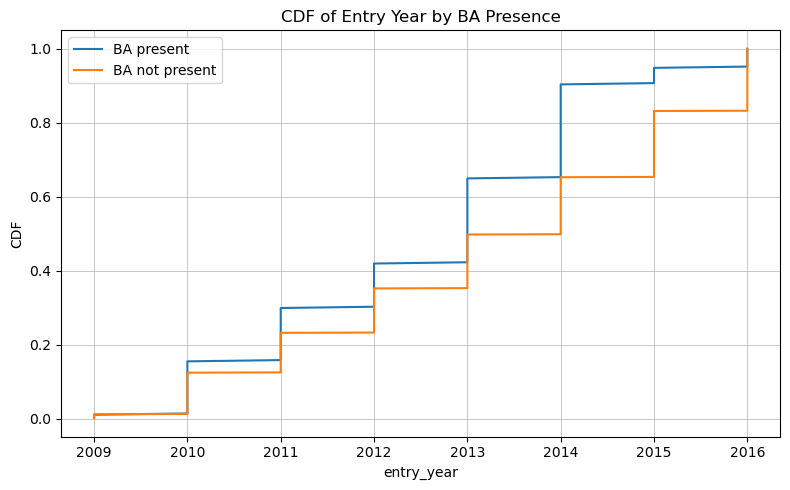

In [209]:
def ecdf(x):
    x = np.asarray(x)
    x = x[~np.isnan(x)]
    x_sorted = np.sort(x)
    y = np.arange(1, len(x_sorted) + 1) / len(x_sorted)
    return x_sorted, y

x1, y1 = ecdf(ba_present["entry_year"].to_numpy())
x0, y0 = ecdf(ba_not_present["entry_year"].to_numpy())

plt.figure(figsize=(8, 5))
plt.plot(x1, y1, label="BA present")
plt.plot(x0, y0, label="BA not present")
plt.xlabel("entry_year")
plt.ylabel("CDF")
plt.title("CDF of Entry Year by BA Presence")
plt.grid(True, linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

I was suprised to find that for almost every year the majority of entries listed a business associate present. After looking at this data and from what we can interpret from the PMF's, we might hypothesize that data breaches involving a business associate affect less individuals overall even though they occur more frequently. 

# Analytical Distribution Plot

In [212]:
def InterpolateSample(df, log_upper=6.0):
   
    df['log_upper'] = np.log10(df['entry_date'])

    df['log_lower'] = df.log_upper.shift(1)
    df.loc[0, 'log_lower'] = 3.0

    df.loc[41, 'log_upper'] = log_upper
    
    arrays = []
    for _, row in df.iterrows():
        vals = np.linspace(row.log_lower, row.log_upper, int(row.freq))
        arrays.append(vals)

    log_sample = np.concatenate(arrays)
    return log_sample

In [213]:
def RawMoment(xs, k):
    return sum(x**k for x in xs) / len(xs)

In [214]:
def Mean(xs):
    return RawMoment(xs, 1)

In [215]:
def CentralMoment(xs, k):
    mean = RawMoment(xs, 1)
    return sum((x - mean)**k for x in xs) / len(xs)

In [216]:
def Var(xs):
    return CentralMoment(xs, 2)

In [217]:
def StandardizedMoment(xs, k):
    var = CentralMoment(xs, 2)
    std = np.sqrt(var)
    return CentralMoment(xs, k) / std**k

In [218]:
def Median(xs):
    """Robust median helper."""
    xs = np.asarray(xs)
    xs = xs[~np.isnan(xs)]
    return float(np.median(xs))


In [219]:
def Skewness(xs):
    return StandardizedMoment(xs, 3)

In [220]:
def PearsonMedianSkewness(xs):
    median = Median(xs)
    mean = RawMoment(xs, 1)
    var = CentralMoment(xs, 2)
    std = np.sqrt(var)
    gp = 3 * (mean - median) / std
    return gp

In [221]:
import numpy as np
import matplotlib.pyplot as plt

affected_counts = (
    df["num_affected"]
    .pipe(pd.to_numeric, errors="coerce")
    .dropna()
    .to_numpy()
)

# filter out 0 or negatives for log-scale plots
affected_counts = affected_counts[affected_counts > 0]

print(f"n={affected_counts.size}, min={affected_counts.min()}, max={affected_counts.max()}")

n=1581, min=501, max=1055489


In [222]:
def ecdf(x: np.ndarray):
    """Return x_sorted and ECDF y values for a 1D numeric array."""
    x_sorted = np.sort(x)
    y = np.arange(1, x_sorted.size + 1) / x_sorted.size
    return x_sorted, y

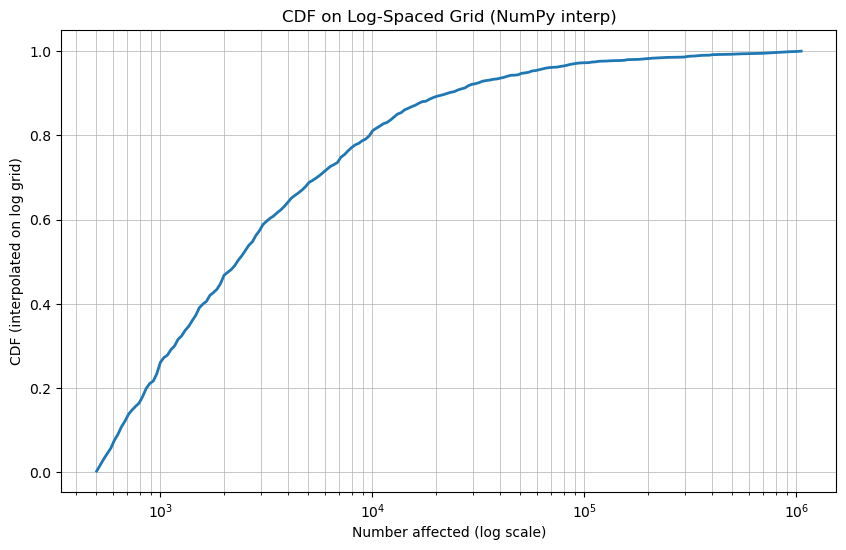

In [223]:
x_sorted, y_cdf = ecdf(affected_counts)

# log-spaced grid across your data range
grid = np.logspace(np.log10(x_sorted.min()), np.log10(x_sorted.max()), 200)

# interpolate the ECDF values onto the grid
y_grid = np.interp(grid, x_sorted, y_cdf)

plt.figure(figsize=(10, 6))
plt.plot(grid, y_grid, linewidth=2)
plt.xscale("log")
plt.xlabel("Number affected (log scale)")
plt.ylabel("CDF (interpolated on log grid)")
plt.title("CDF on Log-Spaced Grid (NumPy interp)")
plt.grid(True, which="both", linewidth=0.5)
plt.show()

The empirical cumulative distribution function (CDF) of the number affected shows a heavy-tailed distribution. Approximately 80% of events affect fewer than 10,000 individuals, while a small fraction of events impact tens of thousands to over one million individuals. This pattern indicates that although most events are relatively small, rare large-scale events contribute disproportionately to overall impact.

# Scatter Plots and Correlation Analysis

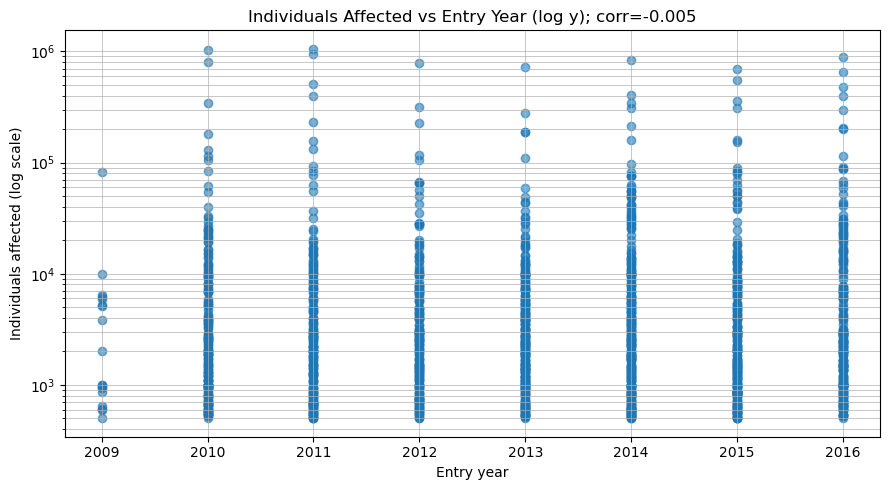

Correlation(entry_year, num_affected) on raw scale: -0.005
Correlation(entry_year, log(num_affected)) on log scale: 0.018


In [226]:
# Clean for correlation/scatter
tmp = df_clean.dropna(subset=["entry_year", "num_affected"]).copy()

x = tmp["entry_year"].to_numpy()
y = tmp["num_affected"].to_numpy()

# Correlation on raw scale (note: heavy skew can distort)
corr_raw = np.corrcoef(x, y)[0, 1]

plt.figure(figsize=(9, 5))
plt.scatter(x, y, alpha=0.6)
plt.yscale("log")
plt.xlabel("Entry year")
plt.ylabel("Individuals affected (log scale)")
plt.title(f"Individuals Affected vs Entry Year (log y); corr={corr_raw:.3f}")
plt.grid(True, which="both", linewidth=0.5)
plt.tight_layout()
plt.show()

# Optional: correlation on log scale (often more stable for heavy-tailed outcomes)
y_log = np.log(y)
corr_log = np.corrcoef(x, y_log)[0, 1]
print(f"Correlation(entry_year, num_affected) on raw scale: {corr_raw:.3f}")
print(f"Correlation(entry_year, log(num_affected)) on log scale: {corr_log:.3f}")

In [227]:
x = df_clean["entry_year"].to_numpy()
y = df_clean["num_affected"].to_numpy()

# Covariance
covariance = np.cov(x, y)[0, 1]

# Correlation
correlation_coefficient = np.corrcoef(x, y)[0, 1]

print(f"Covariance between entry_year and num_affected: {covariance:.2f}")
print(f"Pearson correlation coefficient: {correlation_coefficient:.3f}")

Covariance between entry_year and num_affected: -762.28
Pearson correlation coefficient: -0.005


This visualization allows us to see the distribution of entries over years and the number of individuals they involve. I would have liked to have had two variables to compare like the example in the book that plotted heights and weights. An opportunity for future analysis would be manipulating the data to include new variables to explore relationships with and be able to use Cov and Pearson’s correlation. Because of the pattern seen in the current distribution for num_affected against entry_date, the covariance and Pearson's correlation are irrelevant. 

# Hypothesis Testing

Because breach sizes are heavy-tailed and contain outliers, we avoid assumptions of normality. Instead, we use:

- a **permutation test** on the **median difference** (BA present − BA not present) to assess statistical significance, and
- a **bootstrap confidence interval** to quantify uncertainty around the median difference.

These methods are robust and distribution-free, which is appropriate for this outcome.


In [230]:
df["num_affected"] = pd.to_numeric(df["num_affected"], errors="coerce")
df_clean = df.dropna(subset=["num_affected"]).copy()
df_clean = df_clean[df_clean["num_affected"] > 0]

ba_present = df_clean[df_clean["ba_presence_bin"] == 1]
ba_not_present = df_clean[df_clean["ba_presence_bin"] == 0]

x = ba_present["num_affected"].to_numpy()
y = ba_not_present["num_affected"].to_numpy()

print("n (BA present):", x.size)
print("n (BA not present):", y.size)
print("median affected (BA present):", np.median(x))
print("median affected (BA not present):", np.median(y))
print("mean affected (BA present):", x.mean())
print("mean affected (BA not present):", y.mean())

n (BA present): 291
n (BA not present): 1290
median affected (BA present): 3334.0
median affected (BA not present): 2150.0
mean affected (BA present): 22149.95532646048
mean affected (BA not present): 16376.38527131783


In [231]:
def permutation_test_diff_median(x, y, reps=5000, seed=42):
    rng = np.random.default_rng(seed)
    x = np.asarray(x)
    y = np.asarray(y)

    obs = np.median(x) - np.median(y)
    combined = np.concatenate([x, y])
    n = len(x)

    more_extreme = 0
    for _ in range(reps):
        rng.shuffle(combined)
        x_new = combined[:n]
        y_new = combined[n:]
        stat = np.median(x_new) - np.median(y_new)
        if abs(stat) >= abs(obs):
            more_extreme += 1

    p = more_extreme / reps
    return obs, p

obs_med, p_med = permutation_test_diff_median(x, y, reps=10000, seed=42)
print(f"Observed median diff (BA present - BA not present): {obs_med:,.0f}")
print(f"Permutation p-value (median): {p_med:.4f}")

Observed median diff (BA present - BA not present): 1,184
Permutation p-value (median): 0.0000


In [232]:
def bootstrap_ci_diff_median(x, y, reps=5000, seed=42, ci=95):
    rng = np.random.default_rng(seed)
    x = np.asarray(x)
    y = np.asarray(y)

    stats = np.empty(reps)
    for i in range(reps):
        xb = rng.choice(x, size=len(x), replace=True)
        yb = rng.choice(y, size=len(y), replace=True)
        stats[i] = np.median(xb) - np.median(yb)

    alpha = (100 - ci) / 2
    lo, hi = np.percentile(stats, [alpha, 100 - alpha])
    return lo, hi

lo, hi = bootstrap_ci_diff_median(x, y, reps=10000, seed=42, ci=95)
print(f"95% bootstrap CI for median diff: [{lo:,.0f}, {hi:,.0f}]")


95% bootstrap CI for median diff: [389, 1,990]


In [233]:
n = len(ba_present)

for i in range(7):
    sample = ba_present.sample(n=n, replace=False, random_state=100+i)
    x_s = sample["num_affected"].to_numpy()

    obs, p = permutation_test_diff_median(x_s, y, reps=3000, seed=100+i)
    print(f"n={n:5d} | median diff={obs:10,.0f} | p={p:.4f}")

    n //= 2
    if n < 10:
        break

n=  291 | median diff=     1,184 | p=0.0003
n=  145 | median diff=       710 | p=0.0280
n=   72 | median diff=     1,217 | p=0.0183
n=   36 | median diff=     1,384 | p=0.0463
n=   18 | median diff=     2,074 | p=0.0673


To compare breach impact between organizations with and without business associate (BA) presence, a permutation test on the median number of individuals affected was conducted. Breaches involving BA presence had a higher median impact (3,334 affected) than those without BA presence (2,150 affected), yielding an observed median difference of 1,184 individuals. A permutation test produced a p-value < 0.001, indicating that this difference is highly unlikely to be due to random variation. A bootstrap 95% confidence interval for the median difference ranged from 389 to 1,990 individuals, confirming that breaches with BA involvement typically affect substantially more people. These results suggest that BA presence is associated with larger breach impact, likely reflecting the greater scale and complexity of organizations that rely on business associates rather than a causal effect of BA agreements themselves.

# Regression Analysis

Regression is used here as a **confirmatory** analysis to evaluate whether the association between BA presence and breach impact persists after controlling for **breach type** and **breach location**. Given skewness, a log-transformed outcome is recommended for interpretation.


In [236]:
import statsmodels.formula.api as smf

df["log_num_affected"] = np.log(df["num_affected"])

model_log = smf.ols(
    'log_num_affected ~ breach_type + breach_location + ba_presence_bin',
    data=df
)
results_log = model_log.fit()
print(results_log.summary())

                            OLS Regression Results                            
Dep. Variable:       log_num_affected   R-squared:                       0.127
Model:                            OLS   Adj. R-squared:                  0.079
Method:                 Least Squares   F-statistic:                     2.656
Date:                Mon, 05 Jan 2026   Prob (F-statistic):           5.26e-13
Time:                        20:53:02   Log-Likelihood:                -2732.8
No. Observations:                1581   AIC:                             5632.
Df Residuals:                    1498   BIC:                             6077.
Df Model:                          82                                         
Covariance Type:            nonrobust                                         
                                                                                                                                                          coef    std err          t      P>|t|      [0.025      0

A multiple linear regression model was used to examine whether breach characteristics were associated with the number of individuals affected. Because breach sizes were highly right-skewed, the natural logarithm of the number affected was modeled. After controlling for breach type and breach location, business associate presence remained a significant predictor of breach impact. Breaches involving business associates were associated with a substantially higher number of individuals affected, consistent with the nonparametric permutation test results. This finding suggests that BA involvement is correlated with breach scale even when accounting for observable breach characteristics Although the model explains a modest proportion of variance (R² = 0.127), this is typical for real-world security incident data, where breach impact is influenced by many unobserved organizational factors.

# Discussion

**Interpretation note:** An association between BA presence and breach size does **not** imply that BA agreements cause larger breaches. BA presence may be a proxy for factors like organizational scale, data centralization, vendor dependence, and reporting practices.


It is yet to be determined if data breaches involving business associates affect more individuals. This analysis mostly looked at the number of individuals affected over time after grouping the data entries by year and compared this with the amount of data breaches involving business associates. The findings were inconclusive, but I believe there is a lot of opportunity for future analysis with this dataset and with the right data manipulation prior to analyzing and EDA. 

Some variables I would want to take a closer look at are as follows:
1. Breach Type (breach_type) which can provide insights into the most common and harmful types of breaches
2. Location of Breached Information (breach_location) which could help identify vulnerable area
3. State: looking at data breach trends in highly populated states as compared to smaller states.
   
In conclusion, while the EDA provided valuable insights into the dataset, there are always opportunities for improvement and further exploration. Including additional relevant variables, refining assumptions, and addressing challenges more effectively can enhance the depth and accuracy of future analysis.


# Conclusion

This project examined whether healthcare data breaches involving business associates differ in impact from breaches without third-party involvement. Across multiple analytical approaches—including distributional analysis, nonparametric hypothesis testing, and regression modeling—breaches with business associate presence were consistently associated with larger numbers of individuals affected. Importantly, this relationship appears to reflect organizational scale and complexity rather than a causal effect of business associate agreements themselves. These findings highlight the importance of vendor risk management and coordinated security practices in large, interconnected healthcare data environments.

# References

Major US Health Data Breaches. (2023, January). Www.kaggle.com; Health. <https://www.kaggle.com/datasets/thedevastator/major-us-health-data-breaches/>